<a href="https://colab.research.google.com/github/tranhauhuan452005/AESThuatToan/blob/main/BTL_NMHM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

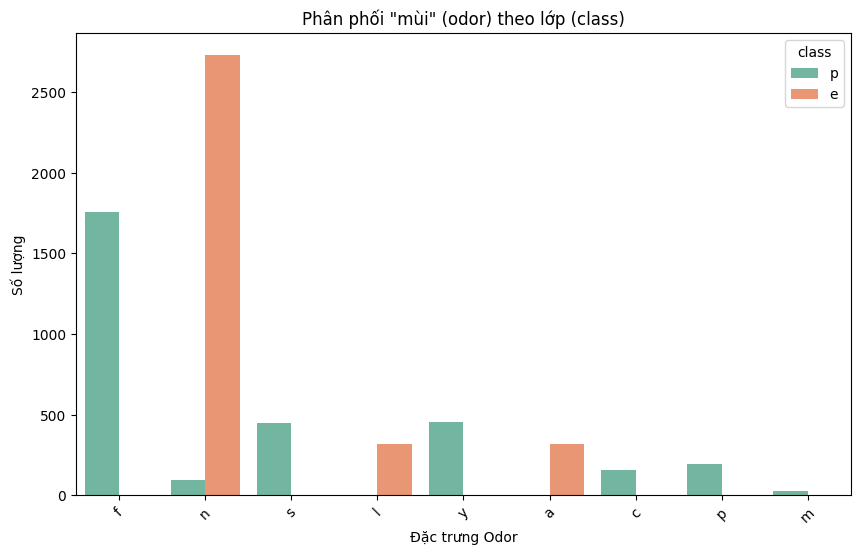

In [ ]:
# Import thêm thư viện
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Giả sử bạn đã load data
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

# Ví dụ: Trực quan hóa mối quan hệ giữa 'odor' và 'class'
plt.figure(figsize=(10, 6))
sns.countplot(data=train, x='odor', hue='class', palette='Set2')
plt.title('Phân phối "mùi" (odor) theo lớp (class)')
plt.xlabel('Đặc trưng Odor')
plt.ylabel('Số lượng')
plt.xticks(rotation=45)
plt.show()

# Ví dụ: Ma trận tương quan (với dữ liệu số sau khi mã hóa)
# Phần này sẽ được thực hiện sau khi tiền xử lý.

In [ ]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Tách biến mục tiêu và đặc trưng
X_train_trad = train.drop(['id', 'class'], axis=1)
y_train_trad = train['class']
X_test_trad = test.drop('id', axis=1)

# Mã hoá biến mục tiêu
le = LabelEncoder()
y_train_trad_encoded = le.fit_transform(y_train_trad)

# Mã hoá One-Hot các đặc trưng
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_trad_encoded = ohe.fit_transform(X_train_trad)
X_test_trad_encoded = ohe.transform(X_test_trad)

# Kiểm tra dữ liệu sau khi mã hoá
print("\\n✅ Luồng A: Dữ liệu sau khi mã hoá One-Hot")
print(f"Số đặc trưng sau mã hoá (Train): {X_train_trad_encoded.shape[1]}")
print(f"Số đặc trưng sau mã hoá (Test): {X_test_trad_encoded.shape[1]}")

\n✅ Luồng A: Dữ liệu sau khi mã hoá One-Hot
Số đặc trưng sau mã hoá (Train): 117
Số đặc trưng sau mã hoá (Test): 117


In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Tách biến mục tiêu và đặc trưng
X_train_auto = train.drop(['id', 'class'], axis=1)
y_train_auto = train['class']
X_test_auto = test.drop('id', axis=1)

# Chuyển đổi tất cả đặc trưng về dạng số bằng LabelEncoder
# Đây là bước tiền xử lý cần thiết trước khi dùng Autoencoder
X_combined = pd.concat([X_train_auto, X_test_auto], axis=0)
for column in X_combined.columns:
    if X_combined[column].dtype == 'object':
        le_temp = LabelEncoder()
        X_combined[column] = le_temp.fit_transform(X_combined[column])

X_train_auto_encoded = X_combined[:len(X_train_auto)]
X_test_auto_encoded = X_combined[len(X_train_auto):]

# Huấn luyện Autoencoder
input_dim = X_train_auto_encoded.shape[1]
encoding_dim = 16  # Kích thước của lớp bottleneck, có thể điều chỉnh

input_layer = Input(shape=(input_dim,))
encoder = Dense(64, activation="relu")(input_layer)
encoder = Dense(encoding_dim, activation="relu")(encoder)
decoder = Dense(64, activation="relu")(encoder)
decoder = Dense(input_dim, activation="sigmoid")(decoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
autoencoder.summary()

# Early Stopping để tránh overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Fit Autoencoder
autoencoder.fit(X_train_auto_encoded, X_train_auto_encoded,
                epochs=100,
                batch_size=32,
                shuffle=True,
                validation_data=(X_test_auto_encoded, X_test_auto_encoded),
                callbacks=[early_stopping])

# Trích xuất đặc trưng mới từ lớp bottleneck
encoder_model = Model(inputs=input_layer, outputs=encoder)
X_train_auto_features = encoder_model.predict(X_train_auto_encoded)
X_test_auto_features = encoder_model.predict(X_test_auto_encoded)

print("\\n✅ Luồng B: Dữ liệu sau khi trích xuất từ Autoencoder")
print(f"Số đặc trưng sau trích xuất (Train): {X_train_auto_features.shape[1]}")
print(f"Số đặc trưng sau trích xuất (Test): {X_test_auto_features.shape[1]}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 22)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 22)             │         1,430 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,030 (19.65 KB)

 Trainable params: 5,030 (19.65 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.4681 - val_loss: 7.1602
Epoch 2/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.1079 - val_loss: 7.1371
Epoch 3/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.1228 - val_loss: 7.1312
Epoch 4/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.0767 - val_loss: 7.1265
Epoch 5/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.1166 - val_loss: 7.1243
Epoch 6/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.1161 - val_loss: 7.1238
Epoch 7/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.1154 - val_loss: 7.1237
Epoch 8/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.1273 - val_loss: 7.1237
Epoch 9/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.1021 - val_loss: 7.1236
Epoch 10/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.0803 - val_loss: 7.1236
Epoch 11/100
204/204 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7.1154 - val_loss: 7.1236
Epoch 12/100
204/204 ━━━━━━━━━━━━━━━━━━━━

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold

# Tạo danh sách các mô hình
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}

# Huấn luyện và đánh giá cho Luồng A (Truyền thống)
print("\\n🚀 Huấn luyện và đánh giá trên Dữ liệu Luồng A (Truyền thống)")
results_trad = {}
for name, model in models.items():
    model.fit(X_train_trad_encoded, y_train_trad_encoded)
    pred = model.predict(X_test_trad_encoded)
    results_trad[name] = pred

# Huấn luyện và đánh giá cho Luồng B (Autoencoder)
print("\\n🚀 Huấn luyện và đánh giá trên Dữ liệu Luồng B (Autoencoder)")
results_auto = {}
for name, model in models.items():
    model.fit(X_train_auto_features, y_train_auto)
    pred = model.predict(X_test_auto_features)
    results_auto[name] = pred

# Sau khi huấn luyện, bạn có thể chọn mô hình tốt nhất từ mỗi luồng để đánh giá chuyên sâu.
# Ví dụ: Chọn RandomForest cho cả hai luồng để so sánh
model_rf_trad = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf_trad.fit(X_train_trad_encoded, y_train_trad_encoded)
pred_trad = model_rf_trad.predict(X_test_trad_encoded)

model_rf_auto = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf_auto.fit(X_train_auto_features, y_train_auto)
pred_auto = model_rf_auto.predict(X_test_auto_features)

# (Lưu ý: Bạn cần có nhãn thực tế của test set để đánh giá.
# Với bài toán Kaggle, bạn chỉ có thể đánh giá trên Leaderboard.)

\n🚀 Huấn luyện và đánh giá trên Dữ liệu Luồng A (Truyền thống)
\n🚀 Huấn luyện và đánh giá trên Dữ liệu Luồng B (Autoencoder)


In [ ]:
# Tạo dataframe để lưu kết quả đánh giá (chỉ có thể đánh giá trên tập train hoặc validation)
# Giả định ta chia tập train thành train/validation để đánh giá
X_train_trad_v, X_val_trad, y_train_trad_v, y_val_trad = train_test_split(
    X_train_trad_encoded, y_train_trad_encoded, test_size=0.2, random_state=42, stratify=y_train_trad_encoded
)
X_train_auto_v, X_val_auto, y_train_auto_v, y_val_auto = train_test_split(
    X_train_auto_features, y_train_auto, test_size=0.2, random_state=42, stratify=y_train_auto
)

# Tạo bảng kết quả
results_table = pd.DataFrame(columns=['Model', 'Feature_Stream', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])

def evaluate_model(model, X, y, stream_name, model_name):
    y_pred = model.predict(X)
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y, y_pred, average='weighted', zero_division=0)
    return pd.DataFrame({
        'Model': [model_name],
        'Feature_Stream': [stream_name],
        'Accuracy': [accuracy],
        'Precision': [precision],
        'Recall': [recall],
        'F1-Score': [f1]
    })

# Đánh giá Luồng A (Truyền thống)
for name, model in models.items():
    model.fit(X_train_trad_v, y_train_trad_v)
    results_table = pd.concat([results_table, evaluate_model(model, X_val_trad, y_val_trad, 'Traditional', name)], ignore_index=True)

# Đánh giá Luồng B (Autoencoder)
for name, model in models.items():
    model.fit(X_train_auto_v, y_train_auto_v)
    results_table = pd.concat([results_table, evaluate_model(model, X_val_auto, y_val_auto, 'Autoencoder', name)], ignore_index=True)

print("\\n📊 Bảng so sánh hiệu suất trên tập Validation")
print(results_table)

/tmp/ipython-input-1870637152.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_table = pd.concat([results_table, evaluate_model(model, X_val_trad, y_val_trad, 'Traditional', name)], ignore_index=True)


\n📊 Bảng so sánh hiệu suất trên tập Validation
                 Model Feature_Stream  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression    Traditional  1.000000   1.000000  1.000000  1.000000
1        Random Forest    Traditional  1.000000   1.000000  1.000000  1.000000
2                  SVM    Traditional  1.000000   1.000000  1.000000  1.000000
3  Logistic Regression    Autoencoder  0.931538   0.931621  0.931538  0.931513
4        Random Forest    Autoencoder  1.000000   1.000000  1.000000  1.000000
5                  SVM    Autoencoder  0.996154   0.996155  0.996154  0.996154


In [ ]:
# Import thêm thư viện cần thiết
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# Giả sử bạn đã tải dữ liệu train và test
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

# Lưu lại các id của test set để tạo file submission
test_ids = test['id']

# Chuẩn bị dữ liệu cho Luồng A (Truyền thống)
X_train_trad = train.drop(['id', 'class'], axis=1)
y_train_trad = train['class']
X_test_trad = test.drop('id', axis=1)

# Mã hoá One-Hot các đặc trưng
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_trad_encoded = ohe.fit_transform(X_train_trad)
X_test_trad_encoded = ohe.transform(X_test_trad)

# Huấn luyện mô hình tốt nhất từ Luồng A
best_model_trad = RandomForestClassifier(n_estimators=100, random_state=42)
best_model_trad.fit(X_train_trad_encoded, y_train_trad)

# Dự đoán trên tập test
pred = best_model_trad.predict(X_test_trad_encoded)

# Tạo dataframe submission
submission = pd.DataFrame({
    'id': test_ids,
    'class': pred
})

# Ghi file CSV
submission.to_csv('submission.csv', index=False)

print("✅ ĐÃ TẠO FILE NỘP: submission.csv (cột id, class = e/p)")
print(submission.head())

✅ ĐÃ TẠO FILE NỘP: submission.csv (cột id, class = e/p)
     id class
0  4632     p
1  3444     p
2  1209     e
3  6880     p
4  4542     p
